### Notebook for replicating Peak finding of Perch 2.0

## Step 1 — Mel Spectrogram

The raw magnitudes are divided by the sum of the Hann window weights to normalise for window energy. The result is then **log-scaled** (base-10), clipped to a floor of 0.01 to avoid log(0), and multiplied by 0.1 to compress the dynamic range into a convenient numerical range around [-0.2, 0].

A mel-spectrogram is computed from the raw audio using a **80 ms window** and a **10 ms hop**. This gives a time resolution of 10 ms per frame and a frequency resolution on the mel scale.

In [1]:
from scipy.signal import find_peaks_cwt
import torchaudio as ta
import torch
import numpy as np
import librosa
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

### Imports

- `matplotlib` — pipeline visualisation

- `torchaudio` / `torch` — mel spectrogram computation and tensor ops- `scipy.signal.find_peaks_cwt` — continuous wavelet transform peak finder
- `librosa` — robust audio loading (avoids FFmpeg dependency issues)

In [2]:
# Sample File - select an arbitrary audio file from train_audio folder
SAMPLE_FILE_PATH = "/home/ftr/kaggle/birdclef-ml-framework/data/train_audio/coffal1/XC972702.ogg"

This is a long recording (~10 min) from species **coffal1** (Coffee-coloured Flowerpiercer). A longer file lets us observe a realistic distribution of bird calls across time and see multiple peaks after the pipeline runs.

In [3]:
# units in ms

MEL_WINDOW_SIZE = 80
MEL_HOP = 10
SAMPLE_RATE = 32000 # 32kHz

Key constants (all time units in milliseconds unless stated):

- **MEL_WINDOW_SIZE = 80 ms** → 2560 samples at 32 kHz- **SAMPLE_RATE = 32 kHz** → matches the Perch model's expected input rate
- **MEL_HOP = 10 ms** → 320 samples; one spectrogram frame every 10 ms

In [4]:
mel = ta.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    win_length=int(MEL_WINDOW_SIZE / 1000 * SAMPLE_RATE),
    hop_length=int(MEL_HOP / 1000 * SAMPLE_RATE),
    n_fft=4096,
    power=1.0,
    center=False,
    mel_scale="htk",
    window_fn=torch.hann_window,
)
    
# apply mel spectrogram to an audio file
# Load using librosa to avoid FFmpeg dependency issues
y, sr = librosa.load(SAMPLE_FILE_PATH, sr=SAMPLE_RATE, mono=True)
waveform = torch.from_numpy(y).unsqueeze(0).float()  # Convert to torch tensor

mel_spec = mel(waveform)

# scale output by recpirocal of sum of window values
window_sum = torch.hann_window(int(MEL_WINDOW_SIZE / 1000 * SAMPLE_RATE)).sum()
mel_spec = mel_spec / window_sum

# apply log with floor of 10^-2 and multiply by 0.1
mel_spec = torch.log10(torch.clamp(mel_spec, min=1e-2)) * 0.1

mel_spec.shape

torch.Size([1, 128, 688097])

## Step 2 — Two-Step Denoising

The goal is to suppress stationary background noise (wind, rain, constant hum) while preserving transient bird calls. The method operates **per frequency bin independently** across the time axis, so each mel bin is denoised based on its own statistics.

### Step 2a — First pass: remove extreme peaks

This removes strong transient artefacts (e.g. clipping noise, sudden loud events) that would otherwise skew the second-pass statistics, making the subsequent threshold less meaningful.

For each frequency bin, the **mean** and **standard deviation** of log-magnitudes are computed across the full time axis. Any frame whose value exceeds `mean + 1.5σ` is set to zero.

In [5]:
# Remove batch dimension if present
mel_spec_2d = mel_spec.squeeze(0) if mel_spec.dim() == 3 else mel_spec
mel_spec_original = mel_spec_2d.clone()  # save for visualization

bins = mel_spec_2d.shape[1]  # time bins
freq_bins = mel_spec_2d.shape[0]  # frequency bins

means = mel_spec_2d.mean(dim=1, keepdim=True)
stddevs = mel_spec_2d.std(dim=1, keepdim=True)

# Discard values GREATER THAN mean + 1.5*std (upper outliers only, per paper)
mask = mel_spec_2d > (means + 1.5 * stddevs)
mel_spec_2d[mask] = 0
mel_spec_after_denoise1 = mel_spec_2d.clone()  # save for visualization

print(f"After first denoising step - shape: {mel_spec_2d.shape}")

After first denoising step - shape: torch.Size([128, 688097])


### Step 2b — Second pass: select signal and mean-shift

The result is a sparse spectrogram where only the most salient frequency-time cells survive — all relative to the local noise floor.

With the extreme values removed, a **second mean and standard deviation** are computed per frequency bin from the remaining values. These are more robust estimates of the background noise floor.

Any value that lies above `mean + 0.75σ` is considered **signal** (i.e. a bird call). The background mean is then **subtracted** from these values, shifting the noise baseline to zero. All other frames are discarded (set to zero).

In [6]:
# Recalculate means and stddevs from remaining values
means = mel_spec_2d.mean(dim=1, keepdim=True)
stddevs = mel_spec_2d.std(dim=1, keepdim=True)

# Select signal: values above mean + 0.75*std
# Shift selected values by the second mean; discard the rest (set to 0)
signal_mask = mel_spec_2d > (means + 0.75 * stddevs)
mel_spec_2d = torch.where(signal_mask, mel_spec_2d - means, torch.zeros_like(mel_spec_2d))
mel_spec_after_denoise2 = mel_spec_2d.clone()  # save for visualization

print(f"After second denoising step - non-zero values: {(mel_spec_2d != 0).sum().item()}")

After second denoising step - non-zero values: 1464825


## Step 3 — Peak Finding

If the recording is shorter than 6 s, it is zero-padded to ensure the wavelet transform has enough context.

The denoised spectrogram is **summed across all frequency bins** to produce a 1D signal over time. Peaks in this signal correspond to moments where bird activity is simultaneously elevated across many frequency bands — a strong indicator of a vocalisation.

SciPy's `find_peaks_cwt` uses a **continuous wavelet transform** to find peaks that are stable across a range of scales (0.5–2 s, probed at 10 evenly-spaced widths). This makes it robust to the exact duration of individual calls.

In [ ]:
# sum denoised spectogram across frequency bins
signal = mel_spec_2d.sum(dim=0)

# if recording is less than 6s pad with zeros to 6s
min_length = int(6 * 1000 / MEL_HOP)
if signal.shape[0] < min_length:
    signal = torch.cat([signal, torch.zeros(min_length - signal.shape[0])])

# use scipy signal.find_peaks_cwt ranging between 0.5 and 2s using 10 wavelet filters
widths = np.linspace(int(0.5 / (MEL_HOP / 1000)), int(2 / (MEL_HOP / 1000)), 10)
peak_indices = find_peaks_cwt(signal.numpy(), widths)
print(f"Found {len(peak_indices)} peaks: {peak_indices}")

## Step 4 — Peak Filtering

Peaks whose window energy falls below `1.5 × mean_signal_magnitude` (over the full recording) are discarded. This threshold ensures that only peaks that are clearly louder than the recording average survive — removing low-energy false positives caused by the wavelet transform finding weak fluctuations.

Not all detected peaks correspond to genuine bird vocalisations. A **600 ms window** is centred on each candidate peak and its total summed magnitude is computed.

In [ ]:
# calculate total value of summed magnitudes in 600 ms windows surrounding each peak
window_size = int(600 / MEL_HOP)

peak_candidates = []
for peak in peak_indices:
    start = max(0, peak - window_size // 2)
    end = min(signal.shape[0], peak + window_size // 2)
    value = signal[start:end].sum().item()
    peak_candidates.append((int(peak), value))

# if total value less than 1.5 times the mean frequency-summed magnitude over the entire recording, peak is discarded
mean_magnitude = signal.mean().item()
threshold = 1.5 * mean_magnitude
peak_candidates = [(idx, val) for idx, val in peak_candidates if val >= threshold]

peak_candidates

[(769, 191.35870361328125),
 (1402, 87.18534851074219),
 (1610, 135.7495574951172),
 (2932, 177.09214782714844),
 (3837, 96.85025024414062),
 (4792, 142.07861328125),
 (5289, 35.77082824707031),
 (5639, 45.235652923583984),
 (5866, 28.252023696899414),
 (6168, 81.24287414550781),
 (6629, 121.1076889038086),
 (7549, 112.68134307861328),
 (8661, 113.84815979003906),
 (9921, 114.90742492675781),
 (11089, 115.4921875),
 (12781, 35.914649963378906),
 (13507, 41.56791687011719),
 (14712, 67.39849853515625),
 (15970, 50.600730895996094),
 (17672, 48.823238372802734),
 (18722, 26.40152931213379),
 (19320, 81.32164001464844),
 (21244, 33.00273132324219),
 (22767, 13.860586166381836),
 (22970, 15.814775466918945),
 (23178, 21.77050018310547),
 (23401, 26.788299560546875),
 (23641, 21.55153465270996),
 (23903, 23.605915069580078),
 (25462, 51.19442367553711),
 (27256, 22.21363067626953),
 (27497, 24.45113182067871),
 (27919, 86.61876678466797),
 (30221, 11.534456253051758),
 (30434, 18.6318702697

## Step 5 — Select Top 5 Peaks

Each selected peak defines the centre of a **6-second window** that will later be passed to the classifier. If no peak passes the threshold (e.g. very quiet recording), the paper's fallback is to simply use the **first 6 seconds** of the recording.

The surviving peaks are **sorted by their window energy** (descending) and the top 5 are kept. These represent the 5 richest moments of bird activity in the recording.

In [ ]:
# sort remaining peaks by summed magnitudes and keep only top 5
top_peaks = sorted(peak_candidates, key=lambda x: x[1], reverse=True)[:5]

# If no peak found, fall back to the first 6s of the recording (per paper)
if len(top_peaks) == 0:
    top_peaks = [(0, signal[:min_length].sum().item())]
    print("No peaks found - falling back to first 6s of recording")

top_peaks

[(523867, 405.7950134277344),
 (234483, 334.3863525390625),
 (202219, 327.98956298828125),
 (522013, 317.0949401855469),
 (519184, 305.4205322265625)]

### Diagnostics

Quick sanity check on the final outputs before visualising.

In [ ]:
print('num peak_candidates:', len(peak_candidates))
print('num top_peaks:', len(top_peaks))
print('first 5 top_peaks:', top_peaks[:5])
print('threshold:', threshold)
print('signal mean:', mean_magnitude)

if len(top_peaks) > 0:
    indices = [p[0] for p in top_peaks]
    values = [p[1] for p in top_peaks]
    print('indices sorted by value desc:', all(values[i] >= values[i+1] for i in range(len(values)-1)))
    print('index range valid:', min(indices) >= 0 and max(indices) < signal.shape[0])

num peak_candidates: 815
num top_peaks: 5
first 5 top_peaks: [(523867, 405.7950134277344), (234483, 334.3863525390625), (202219, 327.98956298828125), (522013, 317.0949401855469), (519184, 305.4205322265625)]
threshold: 0.6053925454616547
signal mean: 0.4035950303077698
indices sorted by value desc: True
index range valid: True


## Step 6 — Visualisation
The four plots below show each stage of the pipeline:

1. **Raw log-mel spectrogram** — the full frequency-time representation after log scaling
2. **After first denoising** — extreme upper-outlier frames zeroed per frequency bin
3. **After second denoising** — only signal frames remain, shifted to a zero baseline
4. **Summed signal + peaks** — the 1D signal over time with the top-5 peaks marked in red

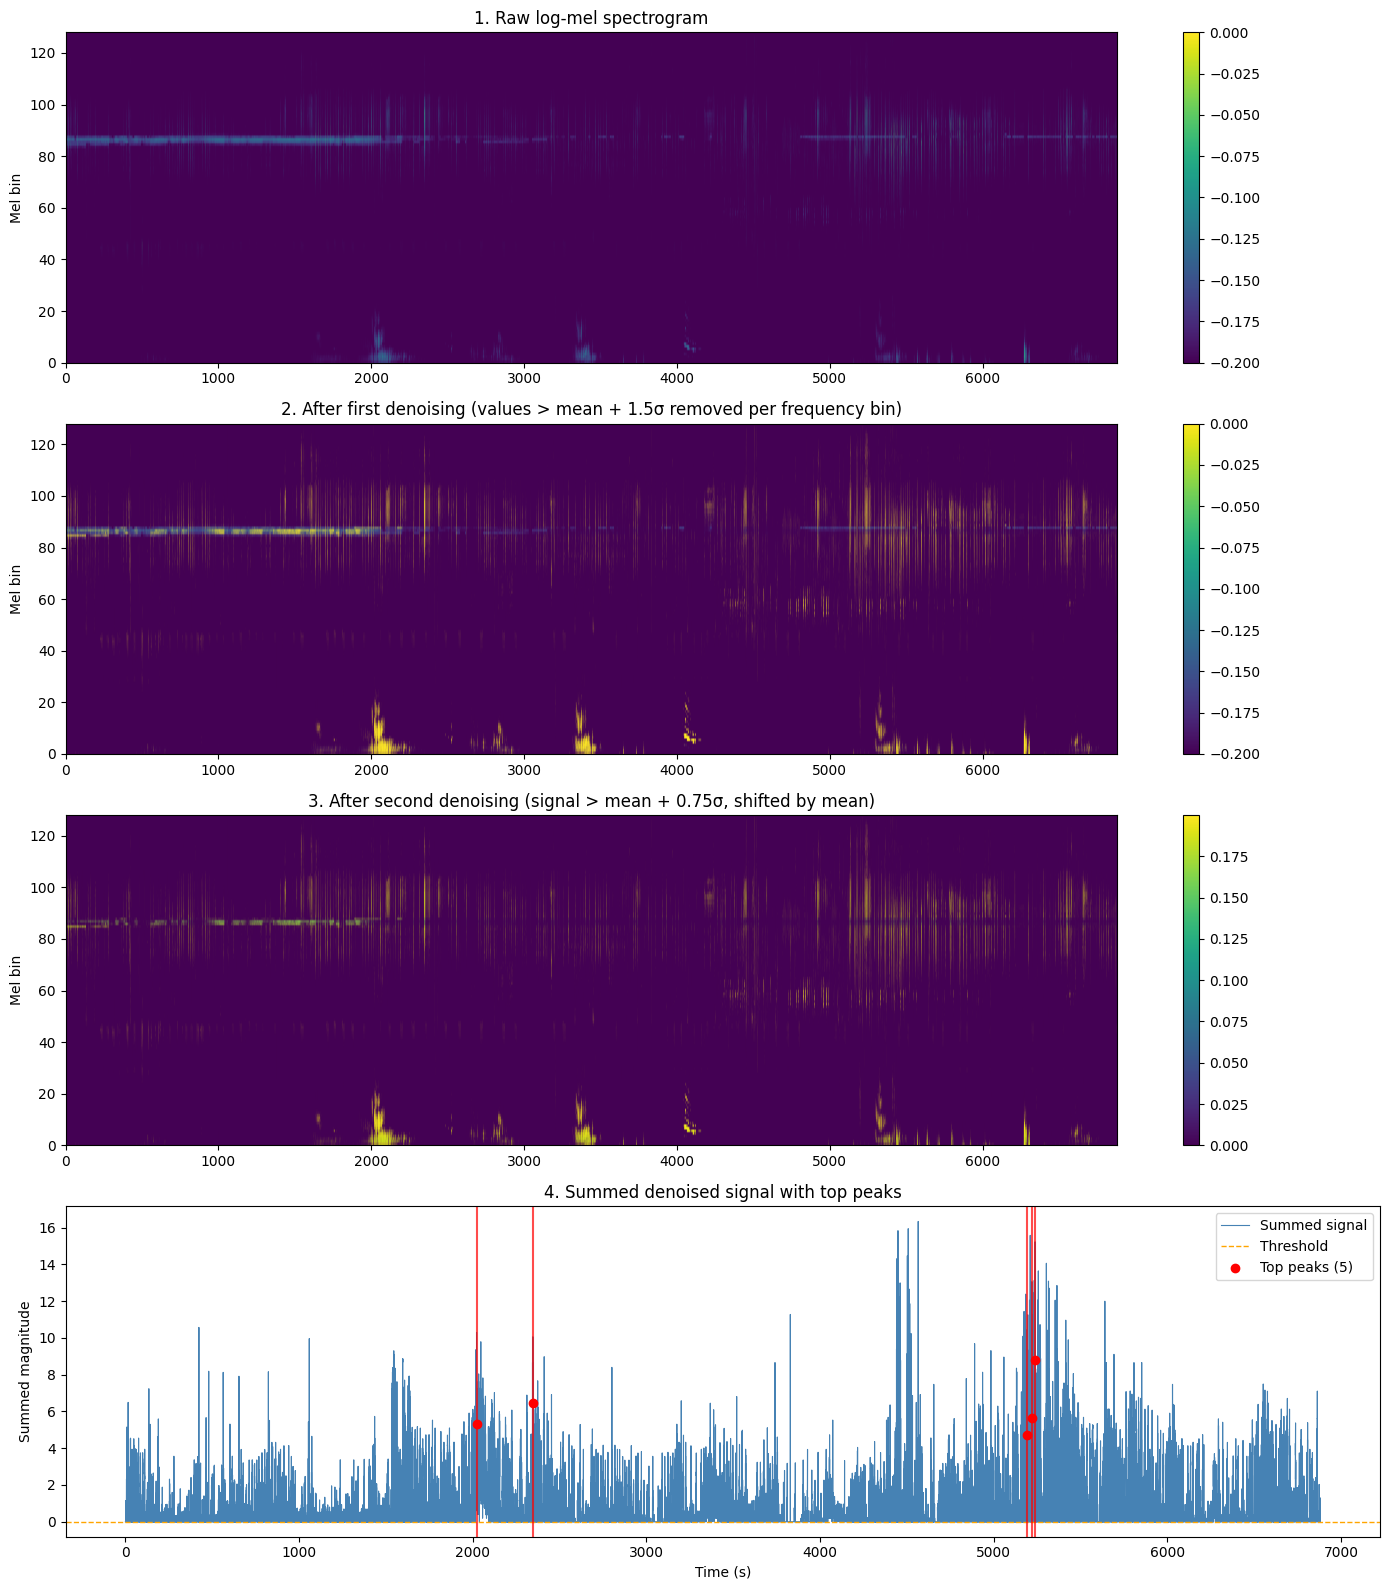

In [ ]:
## Visualization: pipeline overview
duration_s = mel_spec_original.shape[1] * MEL_HOP / 1000
time_axis = np.arange(signal.shape[0]) * MEL_HOP / 1000
top_peak_times = [p[0] * MEL_HOP / 1000 for p in top_peaks]

fig, axes = plt.subplots(4, 1, figsize=(14, 16))

# 1. Raw log-mel spectrogram
ax = axes[0]
img = ax.imshow(mel_spec_original.numpy(), origin='lower', aspect='auto',
                extent=[0, duration_s, 0, mel_spec_original.shape[0]], vmin=-0.2, vmax=0)
ax.set_title('1. Raw log-mel spectrogram')
ax.set_ylabel('Mel bin')
plt.colorbar(img, ax=ax)

# 2. After first denoising (upper outliers removed)
ax = axes[1]
img = ax.imshow(mel_spec_after_denoise1.numpy(), origin='lower', aspect='auto',
                extent=[0, duration_s, 0, mel_spec_after_denoise1.shape[0]], vmin=-0.2, vmax=0)
ax.set_title('2. After first denoising (values > mean + 1.5σ removed per frequency bin)')
ax.set_ylabel('Mel bin')
plt.colorbar(img, ax=ax)

# 3. After second denoising (signal selected and mean-shifted)
ax = axes[2]
img = ax.imshow(mel_spec_after_denoise2.numpy(), origin='lower', aspect='auto',
                extent=[0, duration_s, 0, mel_spec_after_denoise2.shape[0]])
ax.set_title('3. After second denoising (signal > mean + 0.75σ, shifted by mean)')
ax.set_ylabel('Mel bin')
plt.colorbar(img, ax=ax)

# 4. Summed signal with detected top peaks
ax = axes[3]
ax.plot(time_axis, signal.numpy(), color='steelblue', linewidth=0.8, label='Summed signal')
ax.axhline(y=threshold / (window_size), color='orange', linestyle='--', linewidth=1, label='Threshold')
for t in top_peak_times:
    ax.axvline(x=t, color='red', linestyle='-', linewidth=1.5, alpha=0.7)
ax.scatter(top_peak_times, [signal[p[0]].item() for p in top_peaks],
           color='red', zorder=5, label=f'Top peaks ({len(top_peaks)})')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Summed magnitude')
ax.set_title('4. Summed denoised signal with top peaks')
ax.legend()

plt.tight_layout()
plt.show()